# Predicting Singapore HDB Resale Prices

In this notebook you will build three regression models, compare them fairly, and choose one to deploy as a Streamlit web app.

**By the end you will be able to:**
1. Explore a real dataset and turn raw columns into model-ready features.
2. Use a scikit-learn `Pipeline` to one-hot encode text columns.
3. Train **Linear Regression**, **Random Forest** and **Gradient Boosting** regressors.
4. Evaluate regression models with **MAE**, **RMSE** and **R²**.
5. Compare models with **cross-validation** and choose one for deployment, weighing accuracy against size, speed and interpretability.

**Roadmap**

| Part | What we do |
|---|---|
| 1 | Load and inspect the data |
| 2 | Feature engineering |
| 3 | Exploratory data analysis (EDA) |
| 4 | Train/test split and preprocessing |
| 5 | Model 1: Linear Regression |
| 6 | Model 2: Random Forest |
| 7 | Model 3: Gradient Boosting |
| 8 | Fair comparison with cross-validation |
| 9 | Choose, test and explain the final model |
| 10 | From notebook to app |

## Part 0: Setup

In [2]:
%load_ext autoreload
%autoreload 2

import io
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline # for building machine learning pipelines, what is pipelines used for: it allows you to chain preprocessing steps and the model into a single object, making the workflow cleaner and easier to manage
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

# Shared helpers also used by model.py and app.py
from hdb_features import add_features, load_data, storey_midpoint

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.2f}".format)
RANDOM_STATE = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Part 1: Load and inspect the data

The dataset contains HDB resale transactions from **January 2017 to May 2019**, originally published on [data.gov.sg](https://data.gov.sg). A copy lives in `data/` so this notebook works offline.

Each row is one resale transaction.

In [8]:
df = load_data()

month = pd.to_datetime(df['month'])
cutoff = month.max() - pd.DateOffset(months=23)
df = df[month >= cutoff].reset_index(drop=True) # reset_index (drop=True) means the old index is discarded and a new sequential index is used
print(df.shape)
df.head()
df.tail(10)

(48979, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
48969,2026-03,YISHUN,EXECUTIVE,877,YISHUN ST 81,07 TO 09,142.00,Apartment,1987,60 years 10 months,"980,000.00"
48970,2026-04,YISHUN,EXECUTIVE,827,YISHUN ST 81,01 TO 03,145.00,Maisonette,1987,60 years 06 months,"960,000.00"
48971,2026-05,YISHUN,EXECUTIVE,828,YISHUN ST 81,07 TO 09,145.00,Apartment,1988,60 years 09 months,"1,068,888.00"
48972,2026-07,YISHUN,EXECUTIVE,877,YISHUN ST 81,07 TO 09,145.00,Maisonette,1987,60 years 06 months,"1,015,000.00"
48973,2026-07,YISHUN,EXECUTIVE,834,YISHUN ST 81,04 TO 06,146.00,Maisonette,1988,60 years 06 months,"975,000.00"
48974,2026-09,YISHUN,EXECUTIVE,828,YISHUN ST 81,04 TO 06,142.00,Apartment,1988,60 years 05 months,"980,000.00"
48975,2026-09,YISHUN,EXECUTIVE,828,YISHUN ST 81,10 TO 12,146.00,Maisonette,1988,60 years 05 months,"1,010,000.00"
48976,2026-05,YISHUN,MULTI-GENERATION,666,YISHUN AVE 4,04 TO 06,164.00,Multi Generation,1987,60 years 08 months,"1,120,000.00"
48977,2026-09,YISHUN,MULTI-GENERATION,666,YISHUN AVE 4,10 TO 12,151.00,Multi Generation,1987,60 years 04 months,"1,212,000.00"
48978,2026-07,YISHUN,MULTI-GENERATION,605,YISHUN ST 61,07 TO 09,163.00,Multi Generation,1988,60 years 07 months,"1,190,000.00"


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48979 entries, 0 to 48978
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                48979 non-null  str    
 1   town                 48979 non-null  str    
 2   flat_type            48979 non-null  str    
 3   block                48979 non-null  str    
 4   street_name          48979 non-null  str    
 5   storey_range         48979 non-null  str    
 6   floor_area_sqm       48979 non-null  float64
 7   flat_model           48979 non-null  str    
 8   lease_commence_date  48979 non-null  int64  
 9   remaining_lease      48979 non-null  str    
 10  resale_price         48979 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 7.6 MB


In [10]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,"48,979.00","48,979.00","48,979.00"
mean,95.40,"1,998.51","656,152.62"
std,23.92,15.29,"208,353.46"
min,31.00,"1,966.00","238,888.00"
25%,75.00,"1,985.00","510,000.00"
50%,93.00,"1,998.00","630,000.00"
75%,112.00,"2,015.00","770,000.00"
max,195.00,"2,023.00","1,728,000.00"


**What does each column mean, and should we use it?**

| Column | Meaning | Use as a feature? |
|---|---|---|
| `month` | Month of sale | No. Only ~2.5 years of data, and prices were fairly flat over this period |
| `town` | HDB town, e.g. `BISHAN` | **Yes**: location is a key driver of price |
| `flat_type` | `3 ROOM`, `4 ROOM`, `EXECUTIVE`, ... | **Yes** |
| `block`, `street_name` | Address | No. Too many unique values for this lesson |
| `storey_range` | Floor band, e.g. `10 TO 12` | **Yes**, after converting to a number |
| `floor_area_sqm` | Size of the flat | **Yes** |
| `flat_model` | Design, e.g. `Improved`, `DBSS` | Optional (see exercises) |
| `lease_commence_date` | Year the 99-year lease started | **Yes**: older flats have less lease left |
| `remaining_lease` | Text such as `61 years 04 months` | No. Almost the same information as `lease_commence_date` |
| `resale_price` | Price in S$ | **Target**: this is what we predict |

In [11]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 25


There are no missing values. The few duplicate rows can be genuine: two identical flats in the same block can both sell in the same month, so we keep them.

## Part 2: Feature engineering

Models need numbers. `storey_range` is text like `"10 TO 12"`, so we convert each band to its **midpoint**: `"10 TO 12"` becomes `11.0`.

In [12]:
example = pd.Series(["01 TO 03", "10 TO 12", "49 TO 51"])
bounds = example.str.split(" TO ", expand=True).astype(int)
print(bounds)
print("Midpoints:", ((bounds[0] + bounds[1]) / 2).tolist())

    0   1
0   1   3
1  10  12
2  49  51
Midpoints: [2.0, 11.0, 50.0]


In [13]:
# sales_date = pd.to_datetime(df["month"])
# print(sales_date)
# print (df["lease_commence_date"])
# print ("flat_age:")
# print ( sales_date.dt.year + (sales_date.dt.month-1)/12 - df["lease_commence_date"])

parts = df["remaining_lease"].str.extract(r"(\d+)\s*years?(?:\s*(\d+)\s*months?)?")
df["remaining_lease"] = parts[0].astype(int) + parts[1].fillna(0).astype(int) / 12
df.head()


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2024-11,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,01 TO 03,44.00,Improved,1978,52.25,"295,000.00"
1,2024-11,ANG MO KIO,3 ROOM,452,ANG MO KIO AVE 10,01 TO 03,68.00,New Generation,1979,53.83,"380,000.00"
2,2024-11,ANG MO KIO,3 ROOM,153,ANG MO KIO AVE 5,01 TO 03,68.00,New Generation,1981,55.25,"380,000.00"
3,2024-11,ANG MO KIO,3 ROOM,214,ANG MO KIO AVE 3,04 TO 06,67.00,New Generation,1976,50.50,"383,000.00"
4,2024-11,ANG MO KIO,3 ROOM,603,ANG MO KIO AVE 5,04 TO 06,67.00,New Generation,1980,54.67,"388,000.00"


In [14]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2024-11,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,01 TO 03,44.00,Improved,1978,52.25,"295,000.00"
1,2024-11,ANG MO KIO,3 ROOM,452,ANG MO KIO AVE 10,01 TO 03,68.00,New Generation,1979,53.83,"380,000.00"
2,2024-11,ANG MO KIO,3 ROOM,153,ANG MO KIO AVE 5,01 TO 03,68.00,New Generation,1981,55.25,"380,000.00"
3,2024-11,ANG MO KIO,3 ROOM,214,ANG MO KIO AVE 3,04 TO 06,67.00,New Generation,1976,50.50,"383,000.00"
4,2024-11,ANG MO KIO,3 ROOM,603,ANG MO KIO AVE 5,04 TO 06,67.00,New Generation,1980,54.67,"388,000.00"


We put this logic in a function, `storey_midpoint`, inside **`hdb_features.py`**. The training script *and* the web app both import it, so features are always built the same way. If training and serving code compute features differently, the deployed model silently gives wrong answers.

In [15]:
df = add_features(df)
df[["storey_range", "storey"]].drop_duplicates().sort_values("storey").head(10)

,storey_range,storey
0,01 TO 03,2.00
3,04 TO 06,5.00
12,07 TO 09,8.00
8,10 TO 12,11.00
7,13 TO 15,14.00
50,16 TO 18,17.00
55,19 TO 21,20.00
51,22 TO 24,23.00
61,25 TO 27,26.00
137,28 TO 30,29.00


## Part 3: Exploratory data analysis

Before modelling, look at the data. Which columns seem to drive price?

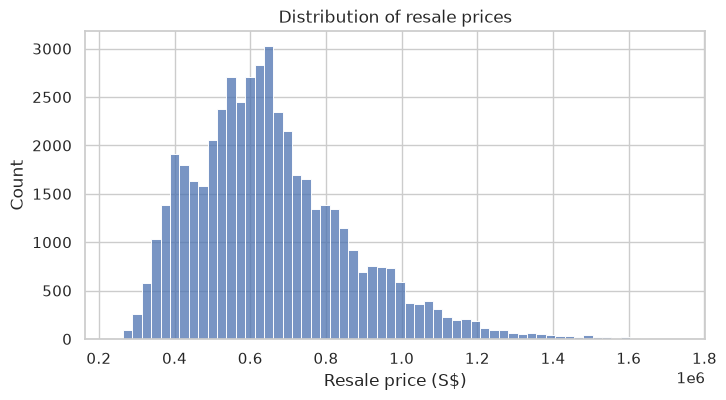

In [16]:
fig, ax = plt.subplots(figsize=(8, 4)) # figure and axis for the plot
sns.histplot(df["resale_price"], bins=60, ax=ax) # Plot histogram of resale prices, what is ax
ax.set(title="Distribution of resale prices", xlabel="Resale price (S$)")
plt.show()

The distribution is **right-skewed**: most flats sell for S$300k to S$500k, with a long tail of expensive flats. Large errors on those expensive flats will dominate Root Mean Square Error (RMSE).

**What is RMSE?**

**RMSE (Root Mean Squared Error)** measures how far the model's predictions are from the actual prices, on average. It is in the same units as the target, so here it is in S\$.

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

where $y_i$ is the actual price, $\hat{y}_i$ is the predicted price, and $n$ is the number of flats.

1. For each flat, take the error: actual price minus predicted price.
2. **Square** each error, then average the squares.
3. Take the square root, which brings the result back to dollars.

**Why large errors on expensive flats dominate**

Squaring weights big errors much more heavily than small ones, and errors on expensive flats tend to be bigger in dollar terms:

| Flat | Actual | Predicted | Error | Absolute error (for MAE) | Squared error (for RMSE) |
|---|---|---|---|---|---|
| Typical | S\$400k | S\$380k | S\$20k | S\$20k | 400 million |
| Expensive | S\$1.2M | S\$1.1M | S\$100k | S\$100k | 10,000 million |
| **Average** | | | | (20k + 100k) ÷ 2 = **MAE = S\$60k** | (400 + 10,000) million ÷ 2 = 5,200 million, then √5,200 million ≈ **RMSE = S\$72.1k** |

The expensive flat's error is 5× larger, but its squared error is **25× larger**. A few expensive flats in the long right tail can push RMSE up a lot, even if the model does well on the S\$300k to S\$500k majority.

**What is MAE?**

**MAE (Mean Absolute Error)** is the average size of the error, ignoring whether the prediction was too high or too low. It is also in S\$.

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}\left|y_i - \hat{y}_i\right|$$

Using the table above, the two errors count as S\$20k and S\$100k: the expensive flat's error is 5× larger and contributes 5× more, not 25×.

**Comparing the two:** for the same two flats, MAE is S\$60k but RMSE is about S\$72.1k. RMSE is always at least as large as MAE. The bigger the gap, the more a few large errors are driving the score.

- **RMSE**: focuses on large errors.
- **MAE**: averages errors without squaring, so it reflects the majority of the sample and is less affected by outliers.

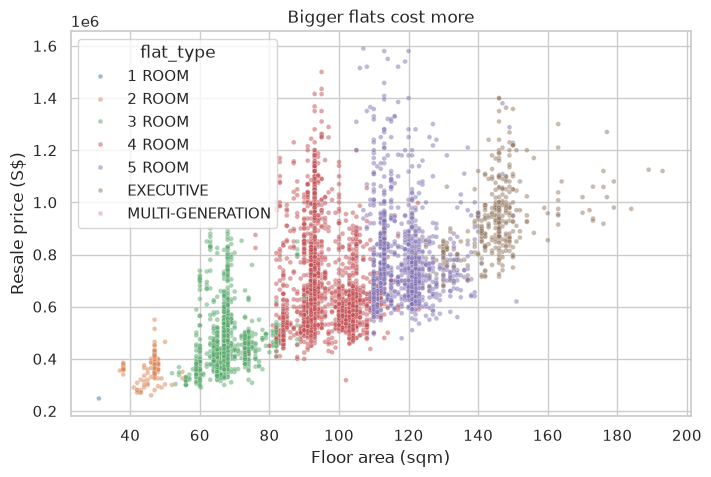

In [17]:
sample = df.sample(5000, random_state=RANDOM_STATE)
order = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE", "MULTI-GENERATION"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample, x="floor_area_sqm", y="resale_price", hue="flat_type",
                hue_order=order, alpha=0.5, s=12, ax=ax)
ax.set(title="Bigger flats cost more", xlabel="Floor area (sqm)", ylabel="Resale price (S$)")
plt.show()

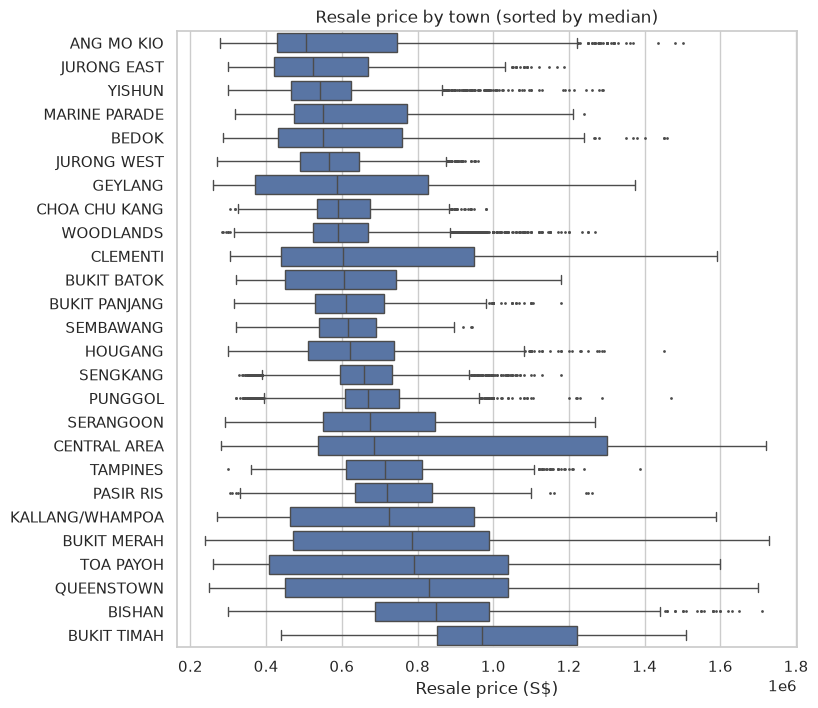

In [18]:
town_order = df.groupby("town")["resale_price"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(data=df, y="town", x="resale_price", order=town_order, fliersize=1, ax=ax)
ax.set(title="Resale price by town (sorted by median)", xlabel="Resale price (S$)", ylabel="")
plt.show()

Location matters a lot: the same size of flat costs far more in central towns than in outer towns. A model that ignores `town` will miss much of the story.

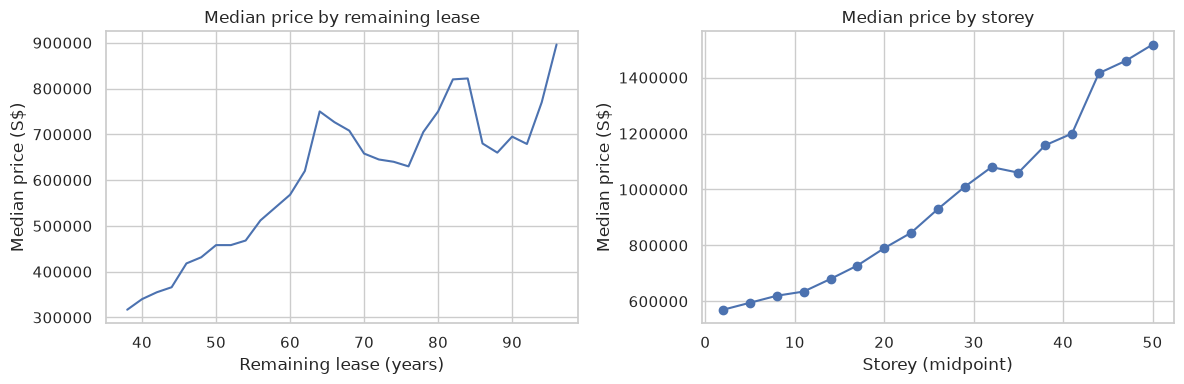

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lease_years = df["remaining_lease"].astype(int)
lease_bins =(df["remaining_lease"]//2)*2 # // means integer division, why not "/"? Using "/" would give a float result, but we want integer bins.
# print(lease_bins)
df.groupby(lease_bins)["resale_price"].median().plot(ax=axes[0])
axes[0].set(title="Median price by remaining lease", xlabel="Remaining lease (years)", ylabel="Median price (S$)")
df.groupby("storey")["resale_price"].median().plot(marker="o", ax=axes[1])
axes[1].set(title="Median price by storey", xlabel="Storey (midpoint)", ylabel="Median price (S$)")
for ax in axes:
    ax.ticklabel_format(style="plain", axis="y") # Ensure y-axis labels are in plain format, the default formatter is ScalarFormatter which may use scientific notation for large numbers
plt.tight_layout()
plt.show()


Newer leases and higher floors both go with higher prices. Notice the curves are **not straight lines**. Keep that in mind when we compare a linear model to tree-based models.

## Part 4: Train/test split and preprocessing

### 4.1 Choose features and split

We hold back **20% of the data as a test set**. We do not look at it until the very end. It stands in for "future flats the model has never seen".

In [20]:
CATEGORICAL_FEATURES = ["town", "flat_type"]
NUMERIC_FEATURES = ["floor_area_sqm", "storey", "remaining_lease"]
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

X = df[FEATURES]
y = df["resale_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Training rows: {len(X_train):,}   Test rows: {len(X_test):,}")

Training rows: 39,183   Test rows: 9,796


Adding flat_model to the categorical_features
Change lease_commence_date to remaining_lease

In [21]:
CATEGORICAL_FEATURES = ["town", "flat_type", "flat_model"]
NUMERIC_FEATURES = ["floor_area_sqm", "storey","remaining_lease"]
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

X = df[FEATURES]
y = df["resale_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (39183, 6)
Test set shape: (9796, 6)


### 4.2 One-hot encoding inside a Pipeline

`town` and `flat_type` are text. **One-hot encoding** turns each category into its own 0/1 column, so `town = BISHAN` becomes `town_BISHAN = 1` and every other town column is 0.

We wrap the encoder and the model in a **`Pipeline`**:
- The encoder is fitted on training data only, so no information leaks from the test set.
- The saved pipeline takes **raw** columns, so the web app can pass in `"BISHAN"` directly.

In [22]:
def build_pipeline(regressor):
    preprocess = ColumnTransformer(
        [("onehot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)],
        remainder="passthrough",  # numeric columns pass through unchanged
    )
    return Pipeline([("preprocess", preprocess), ("model", regressor)])


encoded = build_pipeline(LinearRegression())[0].fit(X_train).get_feature_names_out()
print (build_pipeline(LinearRegression())[0])
print (build_pipeline(LinearRegression())[1])
print(f"{len(FEATURES)} raw columns become {len(encoded)} model inputs, e.g.:")
print(encoded[:3], "...", encoded[-3:])

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehot',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['town', 'flat_type', 'flat_model'])])
LinearRegression()
6 raw columns become 57 model inputs, e.g.:
['onehot__town_ANG MO KIO' 'onehot__town_BEDOK' 'onehot__town_BISHAN'] ... ['remainder__floor_area_sqm' 'remainder__storey'
 'remainder__remaining_lease']


### 4.3 How we measure error

| Metric | Meaning | Good value |
|---|---|---|
| **MAE** (mean absolute error) | Average size of the error in S\$. Easy to explain: "off by S\$X on average" | Lower |
| **RMSE** (root mean squared error) | Like MAE but punishes big misses more | Lower |
| **R²** | Share of price variation explained (1.0 = perfect, 0 = no better than guessing the average) | Higher |

In [23]:
results = {}

def evaluate(name, pipeline):
    """Fit on the training set, score on the test set, and remember the result."""
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    y_pred = pipeline.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "fit_seconds": fit_seconds,
    }
    return pd.Series(results[name], name=name)

### 4.4 A baseline

Always start with a "dumb" baseline that predicts the average price for every flat. Any real model must beat it.

In [24]:
evaluate("Baseline (predict mean)", DummyRegressor(strategy="mean"))

MAE           162,034.80
RMSE          208,938.76
R2                 -0.00
fit_seconds         0.00
Name: Baseline (predict mean), dtype: float64

## Part 5: Model 1, Linear Regression

Linear Regression fits a weighted sum:

$$\text{price} = b_0 + b_1 \cdot \text{floor area} + b_2 \cdot \text{storey} + \dots + b_k \cdot \text{town\_BISHAN} + \dots$$

- **Strengths:** fast, tiny, easy to explain (each coefficient is "S\$ per unit").
- **Weaknesses:** assumes every effect is a straight line and adds up independently. It cannot learn that an extra square metre is worth more in Bishan than in Woodlands.

First, how well does it do with **only the three numeric columns** (no town, no flat type)?

In [26]:
numeric_only = LinearRegression().fit(X_train[NUMERIC_FEATURES], y_train) 
pred = numeric_only.predict(X_test[NUMERIC_FEATURES])
print(f"Numeric features only:  R² = {r2_score(y_test, pred):.3f}   "
      f"MAE = S${mean_absolute_error(y_test, pred):,.0f}")

Numeric features only:  R² = 0.640   MAE = S$92,443


Now add `town` and `flat_type` through our pipeline:

In [27]:
lr = build_pipeline(LinearRegression())
evaluate("Linear Regression", lr)

MAE           53,695.73
RMSE          72,239.40
R2                 0.88
fit_seconds        0.71
Name: Linear Regression, dtype: float64

In [28]:
from sklearn.compose import TransformedTargetRegressor

lr_log = TransformedTargetRegressor(
    regressor=build_pipeline(LinearRegression()),
    func=np.log,          # applied to y_train before fitting
    inverse_func=np.exp,  # applied to predictions afterwards
)
evaluate("Linear Regression (log price)", lr_log)


MAE           46,303.85
RMSE          64,585.94
R2                 0.90
fit_seconds        0.72
Name: Linear Regression (log price), dtype: float64

Adding location and flat type gives a big improvement, which shows that **feature engineering often matters more than the choice of algorithm**.

Because the model is linear, we can read its coefficients directly:

In [29]:
coefs = pd.Series(lr[-1].coef_, index=lr[0].get_feature_names_out())
print("S$ per extra unit (numeric features):")
print(coefs[[f"remainder__{c}" for c in NUMERIC_FEATURES]].round(0))
print("\nLargest town coefficients (higher = pricier location, all else equal):")
print(coefs.filter(like="town_").sort_values(ascending=False).head(5).round(0))

S$ per extra unit (numeric features):
remainder__floor_area_sqm    5,722.00
remainder__storey            5,793.00
remainder__remaining_lease   6,670.00
dtype: float64

Largest town coefficients (higher = pricier location, all else equal):
onehot__town_BUKIT TIMAH     277,642.00
onehot__town_MARINE PARADE   170,814.00
onehot__town_QUEENSTOWN      151,999.00
onehot__town_BISHAN          144,415.00
onehot__town_CENTRAL AREA    138,271.00
dtype: float64


In [30]:
inner = lr_log.regressor_
coefs = pd.Series(inner[-1].coef_, index=inner[0].get_feature_names_out())
pct = (np.exp(coefs) - 1) * 100 # log coefficients to percentage change in price
print ("% change in price per extra unit (numerical features):")
print (pct[[f"remainder__{col}" for col in NUMERIC_FEATURES]].round(2))
print ("\nLargest town coefficients (higher = pricier location, all else equal):")
print (pct.filter(like="town_").sort_values(ascending=False).head(10).round(1))

% change in price per extra unit (numerical features):
remainder__floor_area_sqm    0.89
remainder__storey            0.75
remainder__remaining_lease   1.02
dtype: float64

Largest town coefficients (higher = pricier location, all else equal):
onehot__town_BUKIT TIMAH       40.90
onehot__town_MARINE PARADE     32.40
onehot__town_CENTRAL AREA      28.00
onehot__town_QUEENSTOWN        20.90
onehot__town_BISHAN            20.60
onehot__town_BUKIT MERAH       18.80
onehot__town_TOA PAYOH         14.80
onehot__town_KALLANG/WHAMPOA   14.40
onehot__town_GEYLANG           11.00
onehot__town_SERANGOON          8.50
dtype: float64


## Part 6: Model 2, Random Forest

A **decision tree** asks yes/no questions ("floor area > 100 sqm?", "town is BISHAN?") and predicts the average price of the flats that end up in each leaf.

A **Random Forest** trains many trees, each on a random sample of rows and columns, and **averages** their predictions. Averaging cancels out individual trees' mistakes.

- **Strengths:** captures non-linear effects and interactions automatically; little tuning needed.
- **Weaknesses:** a large file (it stores every tree), slower to predict, harder to explain.

Key settings: `n_estimators` (number of trees) and `min_samples_leaf` (smallest leaf; larger values give simpler trees).

In [31]:
rf = build_pipeline(
    RandomForestRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1,
                          random_state=RANDOM_STATE)
)
evaluate("Random Forest", rf)

MAE           29,998.86
RMSE          44,531.89
R2                 0.95
fit_seconds        7.99
Name: Random Forest, dtype: float64

In [32]:
rf_log = TransformedTargetRegressor(
    regressor=build_pipeline(
        RandomForestRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1,
                              random_state=RANDOM_STATE)
    ),
    func=np.log, inverse_func=np.exp,
)
evaluate("Random Forest (log price)", rf_log)


MAE           29,929.04
RMSE          44,420.55
R2                 0.95
fit_seconds        8.13
Name: Random Forest (log price), dtype: float64

## Part 7: Model 3, Gradient Boosting

**Gradient Boosting** also uses many trees, but builds them **one after another**. Each new small tree tries to fix the errors the previous trees still make. `learning_rate` controls how big each correction is.

- **Strengths:** often the most accurate option on tabular data; the saved model is compact (many shallow trees).
- **Weaknesses:** trees are built one at a time, so training is slower, and more settings need tuning.

Key settings: `n_estimators` (number of rounds), `max_depth` (size of each tree), `learning_rate`.

In [33]:
gb = build_pipeline(
    # GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.1,
                            #   random_state=RANDOM_STATE)
    # GradientBoostingRegressor(n_estimators=1000, max_depth=5, learning_rate=0.05,
                            #    random_state=RANDOM_STATE)
    GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05, max_depth=5,
                          n_iter_no_change=20, validation_fraction=0.1,
                          random_state=RANDOM_STATE)
                           
)
evaluate("Gradient Boosting", gb)

MAE           29,907.12
RMSE          43,033.91
R2                 0.96
fit_seconds       77.18
Name: Gradient Boosting, dtype: float64

### Search settings automatically with cross-validation

The model__ prefix tells the pipeline which step a setting belongs to: "model" is the name given in build_pipeline. Expect this to take roughly 10 to 20 minutes, since it fits 20 settings × 3 folds = 60 models

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

search = RandomizedSearchCV(
    build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    param_distributions={
        "model__n_estimators": randint(300, 1500),
        "model__learning_rate": uniform(0.03, 0.17),     # 0.03 to 0.20
        "model__max_depth": randint(3, 8),
        "model__min_samples_leaf": randint(1, 20),
        "model__subsample": uniform(0.7, 0.3),           # 0.7 to 1.0
    },
    n_iter=20, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=RANDOM_STATE,
)
search.fit(X_train, y_train)
print(search.best_params_)
print(f"Best CV RMSE: S${-search.best_score_:,.0f}")


{'model__learning_rate': np.float64(0.040804919548624016), 'model__max_depth': 7, 'model__min_samples_leaf': 3, 'model__n_estimators': 983, 'model__subsample': np.float64(0.8912672414065639)}
Best CV RMSE: S$42,883


In [ ]:
gb = build_pipeline(
    # GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.1,
                            #   random_state=RANDOM_STATE)
    # GradientBoostingRegressor(n_estimators=1000, max_depth=5, learning_rate=0.05,
                            #    random_state=RANDOM_STATE)
    GradientBoostingRegressor(n_estimators=983, learning_rate=0.04, max_depth=7,
                          n_iter_no_change=20, validation_fraction=0.1, min_samples_leaf=3,
                          random_state=RANDOM_STATE)
                           
)
evaluate("Gradient Boosting", gb)

MAE           29,149.25
RMSE          42,331.00
R2                 0.96
fit_seconds       82.46
Name: Gradient Boosting, dtype: float64

### What HistGradientBoostingRegressor is ?
It's the same idea as GradientBoostingRegressor: trees built one after another, each correcting the errors of the trees before it. The difference is how each tree looks for its splits.

Normal Gradient Boosting tries every possible split value. floor_area_sqm has hundreds of distinct values, so for each tree it checks "area > 31?", "area > 31.5?", "area > 32?" and so on, across 40,000 rows. That's slow.

Hist Gradient Boosting first sorts each numeric column into at most 255 bins (a histogram), for example "area 90–92 sqm". It then only tests splits between bins:

Gradient Boosting	Hist Gradient Boosting
Candidate splits per column	Every distinct value	At most 255 bins
Speed on 40k rows	Slow (your run: ~30s)	Often 10–50× faster
Accuracy	Baseline	Usually about the same; binning loses very little detail
Uses all CPU cores	No	Yes
The same approach is behind LightGBM and XGBoost's fast mode, which are popular in industry and competitions.

In [46]:
from sklearn.ensemble import HistGradientBoostingRegressor


def build_pipeline(regressor, dense=False):
    preprocess = ColumnTransformer(
        [("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=not dense),
          CATEGORICAL_FEATURES)],
        remainder="passthrough",
    )
    return Pipeline([("preprocess", preprocess), ("model", regressor)])

hgb = build_pipeline(
    HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.1,
                                  early_stopping=True, random_state=RANDOM_STATE),
    dense=True,
)
evaluate("Hist Gradient Boosting", hgb)


MAE           29,210.56
RMSE          42,374.00
R2                 0.96
fit_seconds        4.99
Name: Hist Gradient Boosting, dtype: float64

In [47]:
from sklearn.preprocessing import OrdinalEncoder

native = Pipeline([
    ("preprocess", ColumnTransformer(
        [("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
          CATEGORICAL_FEATURES)],
        remainder="passthrough",
    )),
    ("model", HistGradientBoostingRegressor(
        max_iter=1000, learning_rate=0.1, early_stopping=True,
        categorical_features=list(range(len(CATEGORICAL_FEATURES))),   # first columns are categorical
        random_state=RANDOM_STATE,
    )),
])
evaluate("Hist GB (native categories)", native)


MAE           28,806.70
RMSE          41,565.60
R2                 0.96
fit_seconds        1.89
Name: Hist GB (native categories), dtype: float64

In [70]:
gb_log = TransformedTargetRegressor(
    regressor=build_pipeline(
        GradientBoostingRegressor(n_estimators=1000, max_depth=7, learning_rate=0.4,
                                  min_samples_leaf=3, validation_fraction=0.1, n_iter_no_change=20,
                                  random_state=RANDOM_STATE)
    ),
    func=np.log, inverse_func=np.exp,
)
evaluate("Gradient Boosting (log price)", gb_log)


MAE           30,022.98
RMSE          43,689.83
R2                 0.96
fit_seconds        7.49
Name: Gradient Boosting (log price), dtype: float64

In [71]:
hgb_log = TransformedTargetRegressor(regressor=hgb, func=np.log, inverse_func=np.exp)
evaluate("Hist Gradient Boosting (log price)", hgb_log)




MAE           29,054.41
RMSE          42,117.54
R2                 0.96
fit_seconds        4.27
Name: Hist Gradient Boosting (log price), dtype: float64

In [72]:
native_log = TransformedTargetRegressor(regressor=native, func=np.log, inverse_func=np.exp)
evaluate("Hist GB (native categories) (log price)", native_log)

MAE           29,055.97
RMSE          42,062.66
R2                 0.96
fit_seconds        1.69
Name: Hist GB (native categories) (log price), dtype: float64

## Part 8: A fair comparison with cross-validation

So far each model was scored once on the test set. Two problems:
1. One split can be lucky or unlucky.
2. If we pick the winner **by looking at the test set**, the test set is no longer "unseen". Our final score would be optimistic.

**5-fold cross-validation** fixes this. It splits the *training* data into 5 parts, trains on 4 and scores on the 5th, and repeats 5 times. We choose the model using these scores and keep the test set for one final check.

In [38]:
# models = {"Linear Regression": lr, "Random Forest": rf, "Gradient Boosting": gb}
# cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# cv_rows = {}
# for name, pipeline in models.items():
#     scores = cross_validate(
#         pipeline, X_train, y_train, cv=cv, n_jobs=-1,
#         scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
#     )
#     cv_rows[name] = {
#         "CV RMSE": -scores["test_neg_root_mean_squared_error"].mean(),
#         "CV RMSE std": scores["test_neg_root_mean_squared_error"].std(),
#         "CV MAE": -scores["test_neg_mean_absolute_error"].mean(),
#         "CV MAE std": scores["test_neg_mean_absolute_error"].std(),
#         "CV R2": scores["test_r2"].mean(),
#     }

# cv_table = pd.DataFrame(cv_rows).T.sort_values("CV RMSE")
# cv_table

In [73]:
models = {"Linear Regression": lr, "Random Forest": rf, "Gradient Boosting": gb,
          "Linear Regression (log price)": lr_log, "Random Forest (log price)": rf_log, "Gradient Boosting (log price)": gb_log,
          "Hist Gradient Boosting": hgb, "Hist Gradient Boosting (log price)": hgb_log, 
          "Hist GB (native categories)": native,
          "Hist GB (native categories) (log price)": native_log,
          }
# cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# cv_rows = {}
# for name, pipeline in models.items():
#     scores = cross_validate(
#         pipeline, X_train, y_train, cv=cv, n_jobs=-1,
#         scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
#     )
#     cv_rows[name] = {
#         "CV RMSE": -scores["test_neg_root_mean_squared_error"].mean(),
#         "CV RMSE std": scores["test_neg_root_mean_squared_error"].std(),
#         "CV MAE": -scores["test_neg_mean_absolute_error"].mean(),
#         "CV MAE std": scores["test_neg_mean_absolute_error"].std(),
#         "CV R2": scores["test_r2"].mean(),
#     }

# cv_table = pd.DataFrame(cv_rows).T.sort_values("CV RMSE")
# cv_table

In [74]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = {}

def run_cv(name, pipeline):
    """Cross-validate one model and store the result. Skips models already done."""
    if name in cv_rows:
        print(f"{name}: already done, skipping")
        return pd.Series(cv_rows[name], name=name)
    start = time.perf_counter()
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, n_jobs=1,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    )
    cv_rows[name] = {
        "CV RMSE": -scores["test_neg_root_mean_squared_error"].mean(),
        "CV RMSE std": scores["test_neg_root_mean_squared_error"].std(),
        "CV MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "CV MAE std": scores["test_neg_mean_absolute_error"].std(),
        "CV R2": scores["test_r2"].mean(),
    }
    print(f"{name}: done in {time.perf_counter() - start:.0f}s")
    return pd.Series(cv_rows[name], name=name)


In [75]:
run_cv("Linear Regression", lr)


Linear Regression: done in 3s


CV RMSE       73,127.68
CV RMSE std    1,278.91
CV MAE        54,520.47
CV MAE std       708.71
CV R2              0.88
Name: Linear Regression, dtype: float64

In [77]:
run_cv("Linear Regression (log price)", lr_log)


Linear Regression (log price): already done, skipping


CV RMSE       65,170.29
CV RMSE std    1,325.69
CV MAE        46,972.84
CV MAE std       484.87
CV R2              0.90
Name: Linear Regression (log price), dtype: float64

In [78]:
run_cv("Random Forest", rf)


Random Forest: done in 29s


CV RMSE       45,381.93
CV RMSE std      837.03
CV MAE        30,519.87
CV MAE std       281.40
CV R2              0.95
Name: Random Forest, dtype: float64

In [79]:
run_cv("Random Forest (log price)", rf_log)


Random Forest (log price): done in 29s


CV RMSE       45,649.23
CV RMSE std      860.39
CV MAE        30,558.02
CV MAE std       296.44
CV R2              0.95
Name: Random Forest (log price), dtype: float64

In [80]:
run_cv("Gradient Boosting", gb)


Gradient Boosting: done in 300s


CV RMSE       42,942.97
CV RMSE std      829.45
CV MAE        29,780.83
CV MAE std       328.65
CV R2              0.96
Name: Gradient Boosting, dtype: float64

In [81]:
run_cv("Gradient Boosting (log price)", gb_log)


Gradient Boosting (log price): done in 24s


CV RMSE       45,425.06
CV RMSE std      863.18
CV MAE        31,041.45
CV MAE std       352.86
CV R2              0.95
Name: Gradient Boosting (log price), dtype: float64

In [82]:
run_cv("Hist Gradient Boosting", hgb)


Hist Gradient Boosting: done in 15s


CV RMSE       43,780.01
CV RMSE std      959.65
CV MAE        30,436.18
CV MAE std       680.28
CV R2              0.96
Name: Hist Gradient Boosting, dtype: float64

In [83]:
run_cv("Hist GB (native categories)", native)


Hist GB (native categories): done in 8s


CV RMSE       42,426.09
CV RMSE std      641.64
CV MAE        29,528.19
CV MAE std       296.68
CV R2              0.96
Name: Hist GB (native categories), dtype: float64

In [84]:
run_cv("Hist Gradient Boosting (log price)", hgb_log)


Hist Gradient Boosting (log price): done in 16s


CV RMSE       43,800.02
CV RMSE std    1,232.79
CV MAE        30,189.65
CV MAE std       534.20
CV R2              0.96
Name: Hist Gradient Boosting (log price), dtype: float64

In [85]:
run_cv("Hist GB (native categories) (log price)", native_log)


Hist GB (native categories) (log price): done in 8s


CV RMSE       42,765.56
CV RMSE std      599.01
CV MAE        29,533.84
CV MAE std       322.46
CV R2              0.96
Name: Hist GB (native categories) (log price), dtype: float64

In [86]:
cv_table = pd.DataFrame(cv_rows).T.sort_values("CV RMSE")
cv_table


,CV RMSE,CV RMSE std,CV MAE,CV MAE std,CV R2
Hist GB (native categories),"42,426.09",641.64,"29,528.19",296.68,0.96
Hist GB (native categories) (log price),"42,765.56",599.01,"29,533.84",322.46,0.96
Gradient Boosting,"42,942.97",829.45,"29,780.83",328.65,0.96
Hist Gradient Boosting,"43,780.01",959.65,"30,436.18",680.28,0.96
Hist Gradient Boosting (log price),"43,800.02","1,232.79","30,189.65",534.20,0.96
Random Forest,"45,381.93",837.03,"30,519.87",281.40,0.95
Gradient Boosting (log price),"45,425.06",863.18,"31,041.45",352.86,0.95
Random Forest (log price),"45,649.23",860.39,"30,558.02",296.44,0.95
Linear Regression (log price),"65,170.29","1,325.69","46,972.84",484.87,0.90
Linear Regression,"73,127.68","1,278.91","54,520.47",708.71,0.88


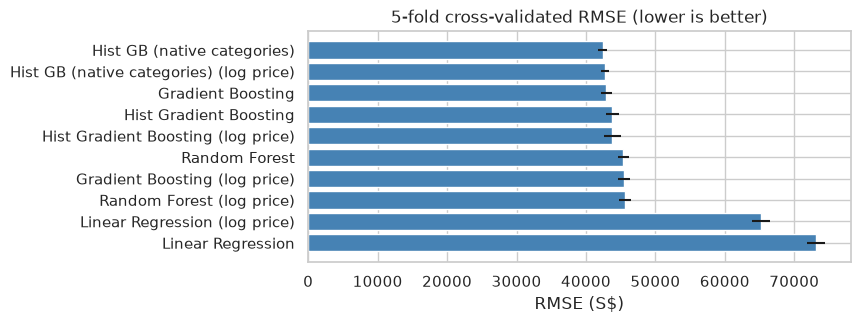

In [87]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(cv_table.index, cv_table["CV RMSE"], xerr=cv_table["CV RMSE std"], color="steelblue")
ax.invert_yaxis()
ax.set(title="5-fold cross-validated RMSE (lower is better)", xlabel="RMSE (S$)")
plt.show()

Accuracy is not the only thing that matters when deploying. Compare model size and speed too:

In [88]:
def size_mb(pipeline):
    buffer = io.BytesIO()
    joblib.dump(pipeline, buffer, compress=3)
    return buffer.tell() / 1e6

def predict_ms(pipeline, n=1000):
    start = time.perf_counter()
    pipeline.predict(X_test.iloc[:n])
    return (time.perf_counter() - start) * 1000

trade_offs = pd.DataFrame({
    name: {
        "Test MAE": results[name]["MAE"],
        "Test R2": results[name]["R2"],
        "Train time (s)": results[name]["fit_seconds"],
        "Predict 1,000 flats (ms)": predict_ms(m),
        "File size (MB)": size_mb(m),
    }
    for name, m in models.items()
}).T
trade_offs

,Test MAE,Test R2,Train time (s),"Predict 1,000 flats (ms)",File size (MB)
Linear Regression,"53,695.73",0.88,0.71,18.27,0.00
Random Forest,"29,998.86",0.95,7.99,348.08,37.47
Gradient Boosting,"29,149.25",0.96,82.46,183.66,3.81
Linear Regression (log price),"46,303.85",0.90,0.72,7.92,0.00
Random Forest (log price),"29,929.04",0.95,8.13,447.34,43.66
Gradient Boosting (log price),"30,022.98",0.96,7.49,16.57,0.37
Hist Gradient Boosting,"29,210.56",0.96,4.99,192.81,1.17
Hist Gradient Boosting (log price),"29,054.41",0.96,4.27,149.21,2.11
Hist GB (native categories),"28,806.70",0.96,1.89,119.79,0.83
Hist GB (native categories) (log price),"29,055.97",0.96,1.69,116.72,1.50


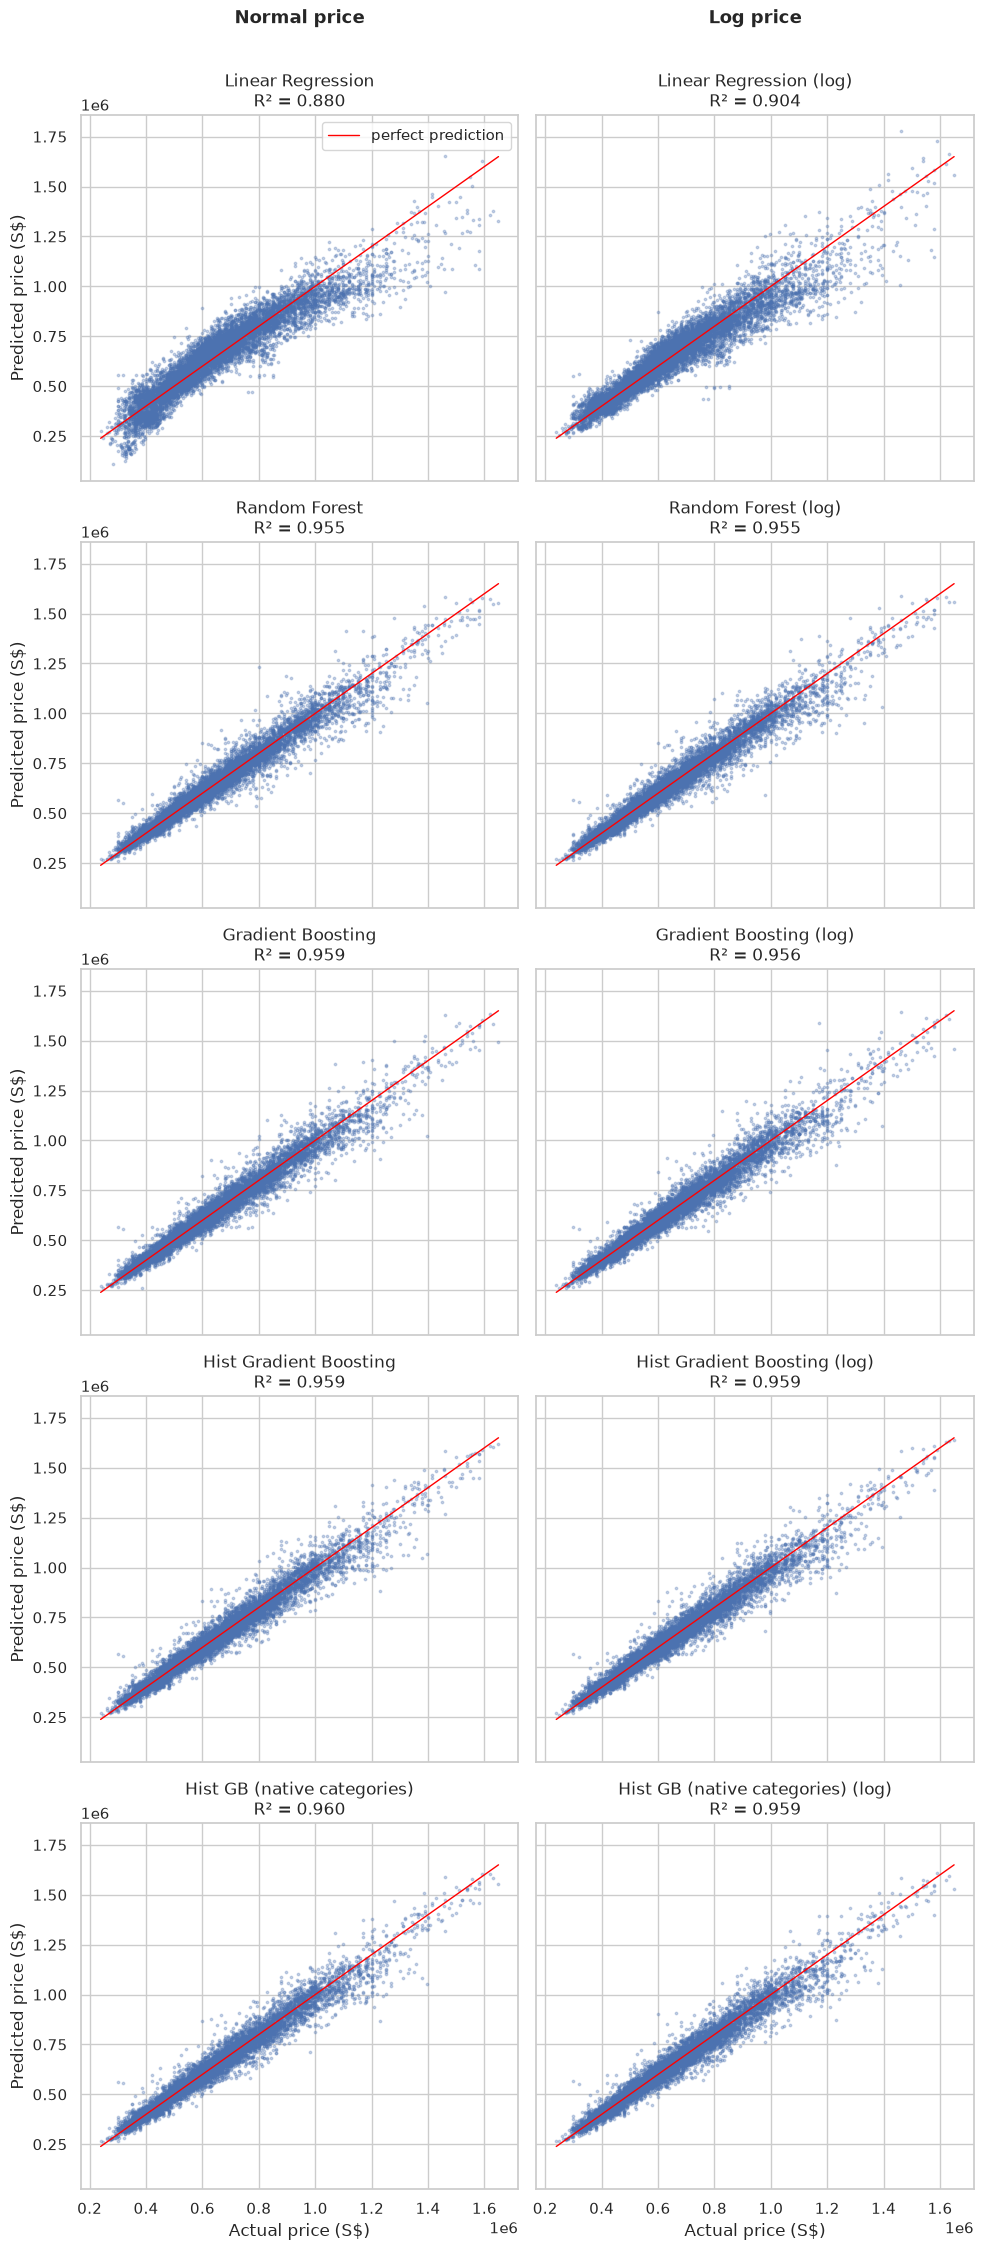

In [89]:
pairs = [
    ("Linear Regression", lr, lr_log),
    ("Random Forest",     rf, rf_log),
    ("Gradient Boosting", gb, gb_log),
    ("Hist Gradient Boosting", hgb, hgb_log),
    ("Hist GB (native categories)", native, native_log),
]

fig, axes = plt.subplots(len(pairs), 2, figsize=(10, 4.5 * len(pairs)),
                         sharex=True, sharey=True, squeeze=False)
lims = [y_test.min(), y_test.max()]

# for row, (label, normal, logged) in enumerate(pairs):
#     for col, (model, suffix) in enumerate([(normal, ""), (logged, " (log)")]):   # col 0 = normal, col 1 = log
#         ax = axes[row, col]
#         pred = model.predict(X_test)
#         ax.scatter(y_test, pred, s=3, alpha=0.3)
#         ax.plot(lims, lims, color="red", lw=1, label="perfect prediction")
#         ax.set(title=f"{label}{suffix}\nR² = {r2_score(y_test, pred):.3f}")
for row, (label, normal, logged) in enumerate(pairs):
    for col, (model, suffix) in enumerate([(normal, ""), (logged, " (log)")]):   # col 0 = normal, col 1 = log
        ax = axes[row, col]
        if model is None:                      # no log version for this model
            ax.text(0.5, 0.5, "No log version", transform=ax.transAxes,
                    ha="center", va="center", color="grey")
            ax.set(title=f"{label}{suffix}")
            continue
        pred = model.predict(X_test)
        ax.scatter(y_test, pred, s=3, alpha=0.3)
        ax.plot(lims, lims, color="red", lw=1, label="perfect prediction")
        ax.set(title=f"{label}{suffix}\nR² = {r2_score(y_test, pred):.3f}")


axes[0, 0].annotate("Normal price", xy=(0.5, 1.25), xycoords="axes fraction",
                    ha="center", fontsize=13, fontweight="bold")
axes[0, 1].annotate("Log price", xy=(0.5, 1.25), xycoords="axes fraction",
                    ha="center", fontsize=13, fontweight="bold")
for ax in axes[-1]:
    ax.set_xlabel("Actual price (S$)")
for ax in axes[:, 0]:
    ax.set_ylabel("Predicted price (S$)")
axes[0, 0].legend()
plt.tight_layout()
plt.show()


**Discuss before moving on:**
- Why do both tree models beat Linear Regression by so much? (Hint: look back at the curved lines in Part 3.)
- Random Forest and Gradient Boosting are close in accuracy. Which differences in the trade-off table would matter for a web app?
- When would you still choose Linear Regression?

## Part 9: Choose, test and explain the final model

**Selection rule:** choose the model with the lowest cross-validated RMSE. Then report its test-set score once, as our honest estimate of real-world performance.

In [91]:
best_name = cv_table["CV RMSE"].idxmin()
# best_name = cv_table["CV MAE"].idxmin()
best_model = models[best_name]
print(f"Chosen model: {best_name}")
print(f"Test MAE  = S${results[best_name]['MAE']:,.0f}")
print(f"Test RMSE = S${results[best_name]['RMSE']:,.0f}")
print(f"Test R²   = {results[best_name]['R2']:.3f}")

Chosen model: Hist GB (native categories)
Test MAE  = S$28,807
Test RMSE = S$41,566
Test R²   = 0.960


### Where does the model make mistakes?

In [92]:
errors = X_test.assign(actual=y_test, predicted=best_model.predict(X_test))
errors["abs_error"] = (errors["actual"] - errors["predicted"]).abs()
errors.groupby("flat_type")["abs_error"].agg(["mean", "count"]).sort_values("mean")

,mean,count
flat_type,,
2 ROOM,"14,078.90",278
1 ROOM,"18,114.85",5
3 ROOM,"20,703.99",2351
4 ROOM,"27,808.69",4290
5 ROOM,"35,959.56",2229
EXECUTIVE,"46,746.01",643


In [93]:
errors = X_test.assign(actual=y_test, predicted=best_model.predict(X_test))
errors["abs_error"] = (errors["actual"] - errors["predicted"]).abs()
errors.groupby("flat_model")["abs_error"].agg(["mean", "count"]).sort_values("mean")

,mean,count
flat_model,,
2-room,"13,752.17",75
Model A2,"19,327.62",97
Simplified,"21,140.66",393
New Generation,"22,585.20",1087
3Gen,"23,935.32",10
Model A,"26,366.14",3908
Premium Apartment,"27,319.77",913
Standard,"30,796.85",231
Improved,"32,291.03",2285


The average error grows with flat size, because bigger flats cost more and a 5% miss on S$700k is larger than on S$250k. Also check the `count` column: 1 ROOM and MULTI-GENERATION have only a handful of test flats, so we cannot say much about how well the model handles them. Always tell users where your model is weak or untested.

### Which features matter most?

**Permutation importance** shuffles one column at a time and measures how much worse the model gets. It works on the raw columns, so `town` is scored as a single feature rather than 26 one-hot columns.

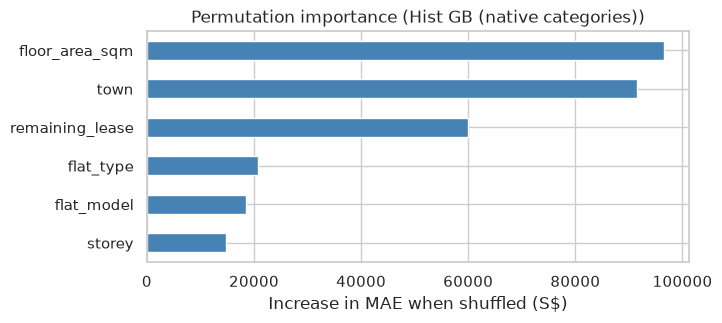

In [94]:
perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)
importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
ax = importance.plot.barh(figsize=(7, 3), color="steelblue")
ax.set(title=f"Permutation importance ({best_name})", xlabel="Increase in MAE when shuffled (S$)")
plt.show()

## Part 10: From notebook to app

A notebook is great for exploring. For deployment we want a script that runs the same steps every time. **`model.py`** does exactly what this notebook did:

1. Loads the data and adds the `storey` feature (via `hdb_features.py`)
2. Trains the same three pipelines with the same settings
3. Compares them with 5-fold cross-validation and picks the lowest CV RMSE
4. Saves the winner to `models/hdb_price_model.joblib`
5. Saves `models/model_card.json` with every model's scores plus the towns, flat types and value ranges the app needs

Run it from the terminal:

```bash
python model.py
streamlit run app.py
```

Here is what the app does when you click **Predict**: it builds a one-row DataFrame with the *same column names* and passes it to the pipeline.

In [ ]:
# flat = pd.DataFrame(
#     [["BISHAN", "4 ROOM", 95, 11, 1990]],
#     columns=FEATURES,
# )
# print(f"Predicted price: S${best_model.predict(flat)[0]:,.0f}")

flat_dict = {
    "town": "BISHAN",
    "flat_type": "4 ROOM",
    "flat_model": "Model A",
    "floor_area_sqm": 95,
    "storey": 11,
    "remaining_lease": 70.5,
}

flat = pd.DataFrame([flat_dict])[FEATURES]
print(f"Predicted price: S${best_model.predict(flat)[0]:,.0f}")




Predicted price: S$604,366


## Exercises

1. **More features:** add `flat_model` to `CATEGORICAL_FEATURES`. Does cross-validated RMSE improve? What would you have to change in `app.py`?
2. **Tuning:** try `n_estimators=50` and `min_samples_leaf=5` for Random Forest. How do accuracy and file size change?
3. **Learning rate:** train Gradient Boosting with `learning_rate=0.05` and `n_estimators=1000`. Is it worth the extra training time?
4. **Log target:** prices are right-skewed. Wrap a model in `sklearn.compose.TransformedTargetRegressor(func=np.log, inverse_func=np.exp)`. Does Linear Regression improve?
5. **Fresher data:** download the latest resale data from [data.gov.sg](https://data.gov.sg/datasets?query=hdb+resale) and retrain. How much have prices changed since 2019? (You will need the `month` column as a feature, or train only on recent months.)
6. **Communicate:** write two sentences for a non-technical user explaining how accurate the app is.